# 212 — Raw ERSP clustering (band-aware downsampled 15×30)

Same canonical sample set as 210, but each ERSP is compressed from full-res
(129 × 300 = 38,700 features) to a neuroscience-band-aware 15 × 30 = 450 features
before clustering. Dim reduction before clustering typically lifts silhouettes 2–4×
vs raw 38k-dim space (Becht et al. 2019), and band-aware (vs uniform) spacing keeps
each EEG band (delta, theta, alpha, beta, gamma, HG, HFO sub-bands) represented by
at least one bin.

Outputs land in `outputs/clustering/{kmeans,hierarchical}/rawds/runs/<timestamp>/`.
MOBA picks up the new `rawds` feature_set automatically via index.json.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from sklearn.preprocessing import StandardScaler
from functions.lf_features  import (
    downsample_ersp_to_bands,
    build_X_3d_downsampled,
    FREQ_BANDS_15_TO_400HZ,
)
from functions import lf_cluster_run as R
from functions import lf_blob_clustering_config as cfg

SCRIPT_NAME = '212_raw_downsampled_clustering.ipynb'


## Config

In [2]:
# ── data input ─────────────────────────────
INPUT_DIR = Path(r'\\\\nasac-m2.unige.ch\\m-HumanNeuronLab\\ANALYSIS\\FLM\\Analysis_LoraFanda\\01_FBM_Analysis\\outputs\\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

# ── downsampling ───────────────────────────
# Each tuple = one output freq band (lo_hz, hi_hz). Default = 15 bands spanning
# 1..400 Hz, finer at low freq, coarser at HFO. Override here to tweak.
FREQ_BAND_EDGES = FREQ_BANDS_15_TO_400HZ
FMAX_HZ         = 500.0     # upper edge of the ORIGINAL ERSP freq axis (Hz).
                            # If your ERSP was computed with fmax=400, set this to 400.
TIME_BINS_OUT   = 30        # target time-axis length (300 -> 30 = 10x downsample)

# ── clustering ─────────────────────────────
KMEANS_K_RANGE = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
HC_METHOD      = 'ward'
HC_METRIC      = 'euclidean'
RANDOM_STATE   = cfg.RANDOM_STATE

print('FREQ_BAND_EDGES:')
for i, (lo, hi) in enumerate(FREQ_BAND_EDGES):
    print(f'  bin {i:2d}: {lo:>5.0f}–{hi:>5.0f} Hz')
print(f'FMAX_HZ = {FMAX_HZ}  TIME_BINS_OUT = {TIME_BINS_OUT}')
print(f'Output feature dim per sample = {len(FREQ_BAND_EDGES) * TIME_BINS_OUT}')


FREQ_BAND_EDGES:
  bin  0:     1–    4 Hz
  bin  1:     4–    8 Hz
  bin  2:     8–   13 Hz
  bin  3:    13–   20 Hz
  bin  4:    20–   30 Hz
  bin  5:    30–   50 Hz
  bin  6:    50–   70 Hz
  bin  7:    70–  100 Hz
  bin  8:   100–  130 Hz
  bin  9:   130–  170 Hz
  bin 10:   170–  220 Hz
  bin 11:   220–  270 Hz
  bin 12:   270–  320 Hz
  bin 13:   320–  360 Hz
  bin 14:   360–  400 Hz
FMAX_HZ = 500.0  TIME_BINS_OUT = 30
Output feature dim per sample = 450


## Load canonical dataset (shared across 210/230/231/232/212)

In [3]:
# Loads ERSPs from INPUT_DIR, drops non-neural channels, applies the
# high-activity gate. Same canonical sample set as 210/230/231/232 so
# cross-comparison is valid.
from functions.lf_dataset import prepare_dataset, DEFAULT_CACHE_DIR

df_meta, ersp_list, X_3d_full = prepare_dataset(INPUT_DIR, cache_dir=DEFAULT_CACHE_DIR)
print(f'\nCanonical dataset: {len(df_meta)} samples · X_3d_full.shape={X_3d_full.shape}')
df_meta.head()


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\_dataset\canonical
  1538 samples · X_3d.shape=(1538, 129, 300)

Canonical dataset: 1538 samples · X_3d_full.shape=(1538, 129, 300)


,patient_id,condition,task,electrode,file_path,prop_above_pos,prop_below_neg,high_activity,sample_idx
0,EL030,audio,LM,A_L10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.081550,0.011783,True,0
1,EL030,audio,LM,A_L11,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.100336,0.017183,True,1
2,EL030,audio,LM,A_L12,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.116124,0.025995,True,2
3,EL030,audio,LM,A_L13,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.151602,0.055633,True,3
4,EL030,audio,LM,A_L14,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.155504,0.064031,True,4


## Downsample: 129 × 300 → 15 × 30

Per-band mean across the freq axis (drops everything above `FMAX_HZ` and
compresses to one bin per neuroscience band), then anti-aliased resize
of the time axis from 300 → `TIME_BINS_OUT`. Same skimage `resize` used
by `lf_minus101.downsample_minus101_map`.


In [4]:
X_3d_ds = build_X_3d_downsampled(
    ersp_list,
    freq_band_edges=FREQ_BAND_EDGES,
    fmax_hz=FMAX_HZ,
    time_bins_out=TIME_BINS_OUT,
)
print('X_3d_ds.shape:', X_3d_ds.shape)

X_raw = X_3d_ds.reshape(X_3d_ds.shape[0], -1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print('X_scaled.shape:', X_scaled.shape, '  (n_samples × 450)')
print('Mean ~0, std ~1?  mean[:5]:', X_scaled[:, :5].mean(axis=0).round(3))
print('                  std[:5]: ', X_scaled[:, :5].std(axis=0).round(3))


[build_X_3d_downsampled] 1538 samples · 15 freq bins · 30 time bins · flat dim = 450
X_3d_ds.shape: (1538, 15, 30)
X_scaled.shape: (1538, 450)   (n_samples × 450)
Mean ~0, std ~1?  mean[:5]: [-0. -0. -0.  0. -0.]
                  std[:5]:  [1. 1. 1. 1. 1.]


## QC: sanity-check a grid of downsampled ERSPs

Pick 20 random samples and plot their downsampled ERSP. The gross spectro-
temporal pattern should be visible — HG should be a clear stripe, beta
should be visible at low freq, baseline should be ~0.


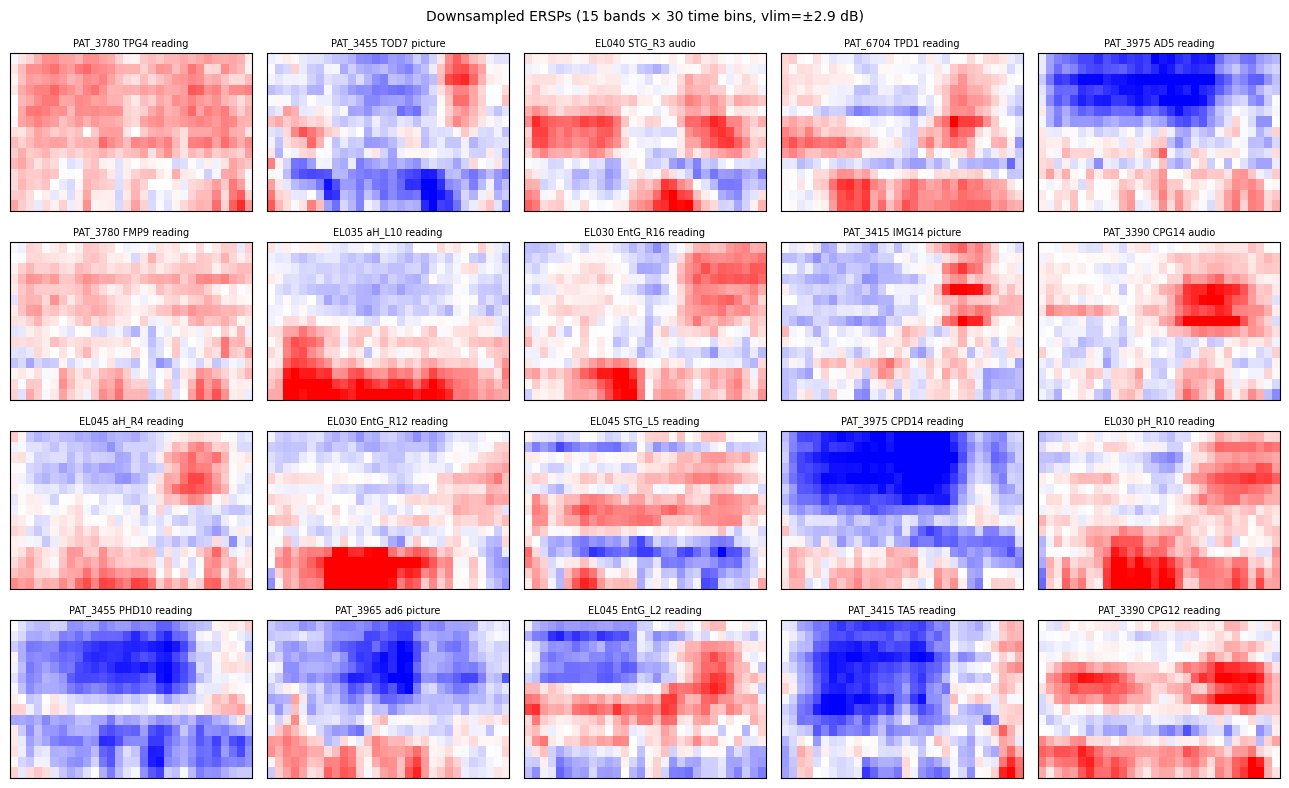

In [5]:
rng = np.random.default_rng(42)
qc_idx = rng.choice(len(X_3d_ds), size=min(20, len(X_3d_ds)), replace=False)

n_cols = 5
n_rows = int(np.ceil(len(qc_idx) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 2.0 * n_rows))
axes = np.atleast_1d(axes).ravel()
vlim = float(np.percentile(np.abs(X_3d_ds[qc_idx]), 98))
for ax, i in zip(axes, qc_idx):
    ax.imshow(X_3d_ds[i], aspect='auto', origin='lower', cmap='bwr',
              vmin=-vlim, vmax=vlim, interpolation='nearest')
    m = df_meta.iloc[int(i)]
    ax.set_title(f"{m['patient_id']} {m['electrode']} {m['condition']}", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[len(qc_idx):]:
    ax.axis('off')
fig.suptitle(f'Downsampled ERSPs ({len(FREQ_BAND_EDGES)} bands × {TIME_BINS_OUT} time bins, vlim=±{vlim:.1f} dB)',
             fontsize=10)
plt.tight_layout()
plt.show()


## Per-sample downsampled-ERSP PNGs

Writes one PNG per canonical sample under
`01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY/<pid>/LM/ERSP_rawds/<cond>/<stem>_RAWDS.png`.

MOBA's samples-pane gets a new **DS** toggle button (parallel to ERSP / Blob / −101 / HG) that
swaps every sample card's image to this view. Useful for visually checking how the band-averaging
compressed each sample's spectro-temporal pattern before clustering. Idempotent — skip-if-exists.


In [ ]:
# Per-sample RAWDS PNG generation. Uses the canonical X_3d_ds (built
# above) so each sample's PNG matches exactly the per-sample vector
# the clustering operates on. Writes one PNG per canonical sample
# parallel to the existing ERSP_clean / ERSP_blob / ERSP_minus101 / ERSP_hg trees.
GEN_RAWDS_PNGS = True
FORCE_REGEN    = False

def _rawds_view_path(file_path):
    """ERSP_matrix/<cond>/<stem>.npy -> ERSP_rawds/<cond>/<stem>_RAWDS.png."""
    p = str(file_path).replace('\\', '/')
    if '/ERSP_matrix/' not in p:
        return None
    return Path(p.replace('/ERSP_matrix/', '/ERSP_rawds/').replace('.npy', '_RAWDS.png'))

if not GEN_RAWDS_PNGS:
    print('[skip] GEN_RAWDS_PNGS = False')
else:
    n_total = X_3d_ds.shape[0]
    n_wrote = n_skip = n_bad = 0
    vlim_global = float(np.percentile(np.abs(X_3d_ds), 99))
    print(f'Writing per-sample RAWDS PNGs for {n_total} samples...')
    for i in range(n_total):
        fp = df_meta.iloc[i].get('file_path')
        if not fp:
            n_bad += 1; continue
        out_path = _rawds_view_path(fp)
        if out_path is None:
            n_bad += 1; continue
        try:
            if FORCE_REGEN or not out_path.exists():
                out_path.parent.mkdir(parents=True, exist_ok=True)
                fig, ax = plt.subplots(figsize=(3, 1.5))
                ax.imshow(X_3d_ds[i], aspect='auto', origin='lower',
                          cmap='bwr', vmin=-vlim_global, vmax=vlim_global,
                          interpolation='nearest')
                ax.set_xticks([]); ax.set_yticks([])
                for s in ax.spines.values(): s.set_visible(False)
                fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
                fig.savefig(out_path, dpi=100, bbox_inches='tight', pad_inches=0)
                plt.close(fig)
                n_wrote += 1
            else:
                n_skip += 1
        except Exception as e:
            print(f'  [warn] sample {i}: {e}')
            n_bad += 1
        if (i + 1) % 500 == 0:
            print(f'  ...{i+1}/{n_total}')
    print(f'RAWDS PNGs: wrote {n_wrote}, skipped existing {n_skip}, bad {n_bad}')


# Clustering

Two methods on the same `X_scaled` (450 features per sample): KMeans K-sweep + Hierarchical K-sweep.
Each `fit_and_save` call writes a self-contained run dir at `outputs/clustering/{kmeans,hierarchical}/rawds/runs/<timestamp>/`.


In [6]:
manifest_km = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='kmeans',
    feature_set='rawds',
    params={'k_range': KMEANS_K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    scaler=scaler,
    method_label='K-Means',
    feature_set_label='Raw ERSP (band-aware downsampled 15×30)',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f'Best K (KMeans/rawds, by silhouette): {BEST_K}')


  K= 10  sil=0.0698
  K= 11  sil=0.0758
  K= 12  sil=0.0647
  K= 13  sil=0.0668
  K= 14  sil=0.0582
  K= 15  sil=0.0679
  K= 16  sil=0.0710
  K= 17  sil=0.0653
  K= 18  sil=0.0644
  K= 19  sil=0.0680
  K= 20  sil=0.0771

[KMeans] Best K=20  silhouette=0.0771
[fit_and_save] kmeans/rawds/20260523_223100
  n_samples=1538 n_clusters=20 silhouette=0.077
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\rawds\runs\20260523_223100
Best K (KMeans/rawds, by silhouette): 20


In [7]:
manifest_hc = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='hierarchical',
    feature_set='rawds',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': KMEANS_K_RANGE},
    scaler=scaler,
    method_label='Hierarchical (Ward)',
    feature_set_label='Raw ERSP (band-aware downsampled 15×30)',
    notebook=SCRIPT_NAME,
)
print(f'Best K (HC/rawds, by silhouette): {manifest_hc["summary"]["best_k"]}')


[HC] method=ward  metric=euclidean  n=1538  cophenetic_r=0.501
  HC sweep k=10: silhouette=0.072
  HC sweep k=11: silhouette=0.070
  HC sweep k=12: silhouette=0.073
  HC sweep k=13: silhouette=0.055
  HC sweep k=14: silhouette=0.058
  HC sweep k=15: silhouette=0.044
  HC sweep k=16: silhouette=0.049
  HC sweep k=17: silhouette=0.041
  HC sweep k=18: silhouette=0.045
  HC sweep k=19: silhouette=0.047
  HC sweep k=20: silhouette=0.049
[fit_and_save] hierarchical/rawds/20260523_223119
  n_samples=1538 n_clusters=12 silhouette=0.073
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hierarchical\rawds\runs\20260523_223119
Best K (HC/rawds, by silhouette): 12


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Mean downsampled ERSP per cluster, plotted as the 15×30 imshow. Cheap to re-run.


In [8]:
# BACKFILL_CENTROIDS — per-cluster mean of the 15×30 downsampled ERSP
import json

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
INDEX_PATH = CLUSTERING_DIR / 'index.json'

def _save_per_cluster_centroid_pngs_rawds(manifest, X_3d_local, *, vlim=5.0):
    if manifest['feature_set'] != 'rawds':
        return 0
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    cluster_col = f"cluster_{manifest['method']}_{manifest['feature_set']}"
    df = pd.read_csv(run_dir / 'labels.csv')
    if cluster_col not in df.columns:
        cands = [c for c in df.columns if c.startswith('cluster_')]
        if not cands: return 0
        cluster_col = cands[0]
    labels = df[cluster_col].to_numpy()
    if len(labels) != X_3d_local.shape[0]:
        print(f"  [skip] {manifest['run_id']}: labels ({len(labels)}) vs X_3d_ds ({X_3d_local.shape[0]}) mismatch")
        return 0
    out_dir = run_dir / 'cluster_centroids'
    out_dir.mkdir(parents=True, exist_ok=True)
    uniq = sorted(int(c) for c in np.unique(labels))
    for c in uniq:
        idx = np.where(labels == c)[0]
        mean_ersp = X_3d_local[idx].mean(axis=0)   # already (n_freq_out, n_time_out)
        fig, ax = plt.subplots(figsize=(2, 1.5))
        ax.imshow(mean_ersp, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.savefig(out_dir / f'cluster_{int(c):02d}.png', dpi=80, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    return len(uniq)

if INDEX_PATH.exists():
    with open(INDEX_PATH) as f:
        idx = json.load(f)
    runs = [r for r in idx.get('runs', []) if r['feature_set'] == 'rawds']
    print(f'Backfilling for {len(runs)} rawds runs...')
    for run in runs:
        mp = CLUSTERING_DIR / run['path'] / 'manifest.json'
        if not mp.exists(): continue
        manifest = json.loads(mp.read_text())
        n = _save_per_cluster_centroid_pngs_rawds(manifest, X_3d_ds)
        if n: print(f"  [{manifest['method']}/rawds] {manifest['run_id']} -> {n} PNGs")
    print('Done.')


Backfilling for 2 rawds runs...
  [hierarchical/rawds] 20260523_223119 -> 12 PNGs
  [kmeans/rawds] 20260523_223100 -> 20 PNGs
Done.
